In [1]:
import pandas as pd

# Load the data
df = pd.read_csv(r"C:\Users\Avilaaa\OneDrive - UT Arlington\Documents\ValkyrieTA_Angela_Avila\food_outbreaks\NationalOutbreak_OutbreakData.csv")
print(df.shape)

# Print all column names first
print("COLUMNS IN DATASET:")
print("="*60)
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")
print("="*60)

# Full breakdown per column
for col in df.columns:
    print(f"\n{'='*60}")
    print(f"COLUMN: {col}")
    print(f"Non-null count: {df[col].notna().sum()} / {len(df)}")
    print(f"Unique values: {df[col].nunique()}")
    print("-"*40)
    
    counts = df[col].value_counts(dropna=False)
    top10 = counts.head(10)
    remaining = len(counts) - 10

    if df[col].dtype in ['int64', 'float64']:
        print(top10.sort_index().to_string())
    else:
        print(top10.to_string())
    
    if remaining > 0:
        print(f"\n(+ {remaining} other unique values not shown)")
    
    print(f"{'='*60}")

(46024, 21)
COLUMNS IN DATASET:
1. Year
2. Month
3. State
4. Primary Mode
5. Etiology
6. Serotype or Genotype
7. Etiology Status
8. Setting
9. Illnesses
10. Hospitalizations
11. Info on Hospitalizations
12. Deaths
13. Info on Deaths
14. Food Vehicle
15. Food Contaminated Ingredient
16. IFSAC Category
17. Water Exposure
18. Water Type
19. Animal Type
20. Animal Type Specify
21. Water Status

COLUMN: Year
Non-null count: 46024 / 46024
Unique values: 20
----------------------------------------
Year
2000    1403
2009    2246
2010    3039
2011    3087
2012    3896
2013    3938
2014    3917
2015    4178
2016    4278
2017    4060

(+ 10 other unique values not shown)

COLUMN: Month
Non-null count: 46024 / 46024
Unique values: 12
----------------------------------------
Month
1     6224
2     5838
3     5473
4     4056
5     3336
6     2849
7     2596
8     2506
11    3180
12    5315

(+ 2 other unique values not shown)

COLUMN: State
Non-null count: 46024 / 46024
Unique values: 55
-----------

In [2]:
# Checking completeness
#check data for completeness 
import matplotlib.pyplot as plt
missing_df = pd.DataFrame({'Missing Count': df.isna().sum()})
missing_df['Missing %'] = (missing_df['Missing Count'] / len(df) * 100).round(1)
missing_df['Filled %'] = (100 - missing_df['Missing %']).round(1)
missing_df = missing_df.sort_values('Filled %', ascending=True)

missing_df = missing_df.sort_values('Filled %', ascending=False)

print(missing_df.to_string())

                              Missing Count  Missing %  Filled %
Illnesses                                 0        0.0     100.0
Primary Mode                              0        0.0     100.0
Year                                      0        0.0     100.0
Month                                     0        0.0     100.0
State                                     0        0.0     100.0
Setting                                6084       13.2      86.8
Deaths                                 6358       13.8      86.2
Hospitalizations                       6431       14.0      86.0
Etiology                              12964       28.2      71.8
Etiology Status                       12964       28.2      71.8
Info on Deaths                        16155       35.1      64.9
Info on Hospitalizations              16216       35.2      64.8
Serotype or Genotype                  34807       75.6      24.4
Food Vehicle                          35151       76.4      23.6
IFSAC Category           

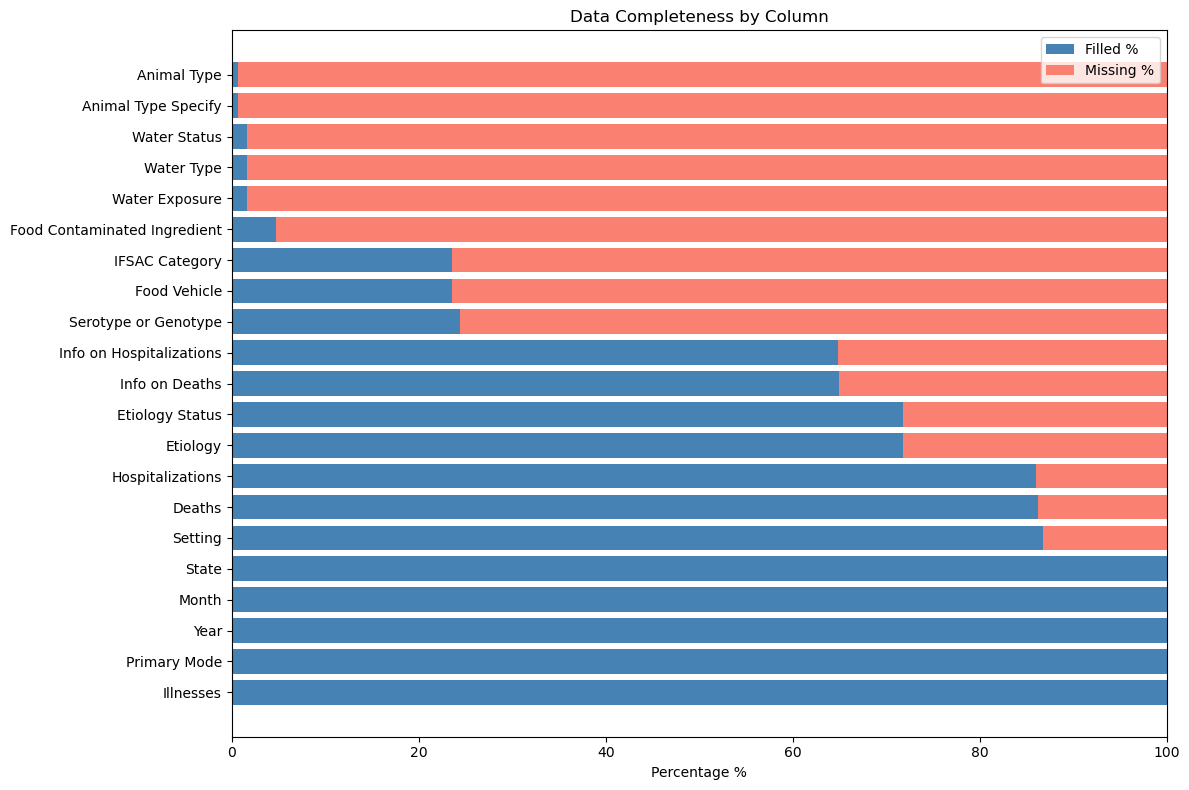

In [3]:

# Bar chart
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(missing_df.index, missing_df['Filled %'], color='steelblue')
ax.barh(missing_df.index, missing_df['Missing %'], left=missing_df['Filled %'], color='salmon')

ax.set_title('Data Completeness by Column')
ax.set_xlabel('Percentage %')
ax.set_xlim(0, 100)
ax.legend(['Filled %', 'Missing %'])
plt.tight_layout()
plt.show()

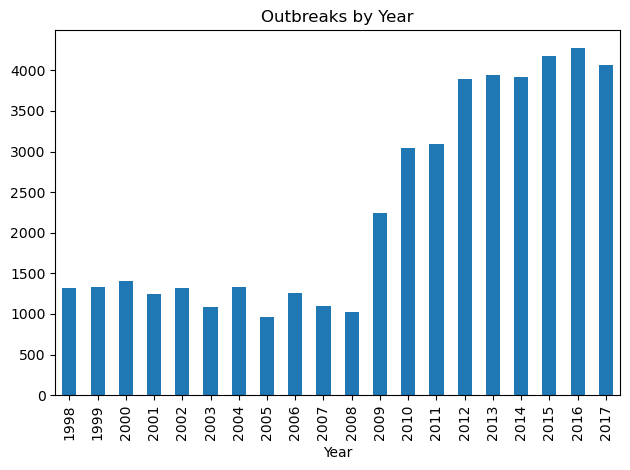

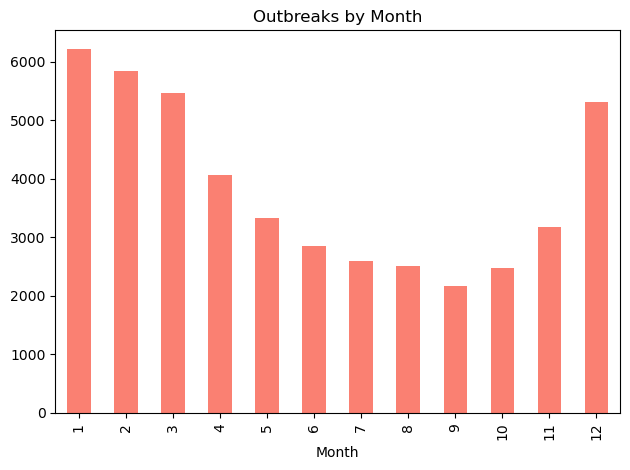

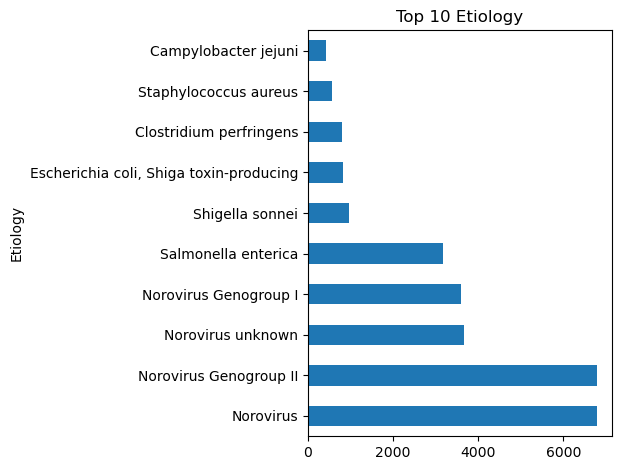

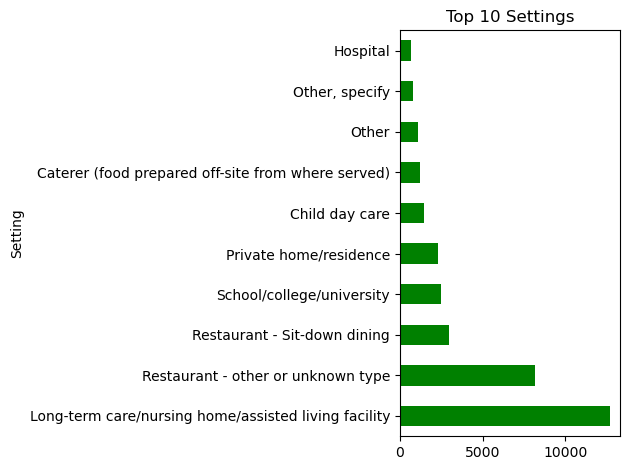

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Outbreaks over time
df.groupby('Year').size().plot(kind='bar', title='Outbreaks by Year')
plt.tight_layout()
plt.show()

# 2. Outbreaks by month
df.groupby('Month').size().plot(kind='bar', title='Outbreaks by Month', color='salmon')
plt.tight_layout()
plt.show()

# 3. Top 10 Etiologies
df['Etiology'].value_counts().head(10).plot(kind='barh', title='Top 10 Etiology')
plt.tight_layout()
plt.show()

# 4. Top 10 Settings
df['Setting'].value_counts().head(10).plot(kind='barh', title='Top 10 Settings', color='green')
plt.tight_layout()
plt.show()

In [5]:
from itertools import combinations

# Automatically find columns that have semicolons
semicolon_cols = [col for col in df.columns if df[col].astype(str).str.contains(';').any()]

# Create count columns in a SEPARATE dataframe so df stays clean
df_semicolons = pd.DataFrame()
for col in semicolon_cols:
    df_semicolons[f'{col}'] = df[col].str.split(';').str.len().fillna(0).astype(int)

# Compare all pairs
count_cols = df_semicolons.columns.tolist()
for col1, col2 in combinations(count_cols, 2):
    matches = (df_semicolons[col1] == df_semicolons[col2]).sum()
    total = len(df)
    pct = round(matches / total * 100, 1)
    print(f"{col1} vs {col2}: {matches}/{total} match ({pct}%)")

Etiology vs Serotype or Genotype: 24096/46024 match (52.4%)
Etiology vs Etiology Status: 46024/46024 match (100.0%)
Etiology vs Setting: 28089/46024 match (61.0%)
Etiology vs Food Vehicle: 16255/46024 match (35.3%)
Etiology vs Food Contaminated Ingredient: 14253/46024 match (31.0%)
Etiology vs Water Type: 13537/46024 match (29.4%)
Etiology vs Animal Type: 13214/46024 match (28.7%)
Etiology vs Animal Type Specify: 13198/46024 match (28.7%)
Serotype or Genotype vs Etiology Status: 24096/46024 match (52.4%)
Serotype or Genotype vs Setting: 13733/46024 match (29.8%)
Serotype or Genotype vs Food Vehicle: 28137/46024 match (61.1%)
Serotype or Genotype vs Food Contaminated Ingredient: 33789/46024 match (73.4%)
Serotype or Genotype vs Water Type: 34780/46024 match (75.6%)
Serotype or Genotype vs Animal Type: 34852/46024 match (75.7%)
Serotype or Genotype vs Animal Type Specify: 34840/46024 match (75.7%)
Etiology Status vs Setting: 28089/46024 match (61.0%)
Etiology Status vs Food Vehicle: 1625

In [6]:
check_cols = ['Etiology', 'Etiology Status']

mask = df['Etiology'].astype(str).str.contains(';', na=False)
print(f"Rows with semicolons in Etiology: {mask.sum()}")
print(f"Rows with semicolons in Etiology Status: {df['Etiology Status'].astype(str).str.contains(';', na=False).sum()}")
print("\nSample multi-etiology rows:")
print('='*60)
print(df.loc[mask, check_cols].head(15).to_string())

Rows with semicolons in Etiology: 1363
Rows with semicolons in Etiology Status: 1363

Sample multi-etiology rows:
                                                                                     Etiology                  Etiology Status
22                                              Norovirus Genogroup I; Norovirus Genogroup II             Confirmed; Confirmed
98                                                  Clostridium other; Norovirus Genogroup II             Suspected; Suspected
102                                                         Norovirus Genogroup II; Rotavirus             Confirmed; Confirmed
128                                              Campylobacter jejuni; Listeria monocytogenes             Confirmed; Confirmed
402                                                Norovirus unknown; Clostridium perfringens             Confirmed; Suspected
435                                                 Norovirus unknown; Staphylococcus unknown             Confirmed; Confirm

In [7]:
import plotly.graph_objects as go

# Calculate completeness per year per column
years = sorted(df['Year'].unique())
completeness_by_year = []
for year in years:
    df_year = df[df['Year'] == year]
    for col in df.columns:
        filled_pct = (df_year[col].notna().sum() / len(df_year) * 100).round(1)
        completeness_by_year.append({'Year': year, 'Column': col, 'Filled %': filled_pct})
completeness_df = pd.DataFrame(completeness_by_year)

# Group ALL columns with identical values together
def get_values(col):
    return tuple(completeness_df[completeness_df['Column'] == col]['Filled %'].values)

grouped = {}
for col in df.columns:
    key = get_values(col)
    if key not in grouped:
        grouped[key] = []
    grouped[key].append(col)

# Plot
fig = go.Figure()

for key, cols in grouped.items():
    col_data = completeness_df[completeness_df['Column'] == cols[0]]
    label = ', '.join(cols)
    fig.add_trace(go.Scatter(
        x=col_data['Year'],
        y=col_data['Filled %'],
        mode='lines+markers',
        name=label
    ))

fig.update_layout(
    title='Data Completeness Over Time by Column',
    xaxis=dict(tickmode='array', tickvals=years, tickangle=90),
    yaxis=dict(title='Filled %'),
    legend=dict(font=dict(size=14)),
    width=1050,
    height=700
)

fig.show()

--- Most Dominant Etiologies ---
NOROVIRUS: 22014 occurrences
GENOGROUP: 11355 occurrences
II: 7516 occurrences
UNKNOWN: 4572 occurrences
I: 3829 occurrences
SALMONELLA: 3646 occurrences
ENTERICA: 3515 occurrences
TOXIN: 1545 occurrences
CLOSTRIDIUM: 1370 occurrences
SHIGELLA: 1176 occurrences


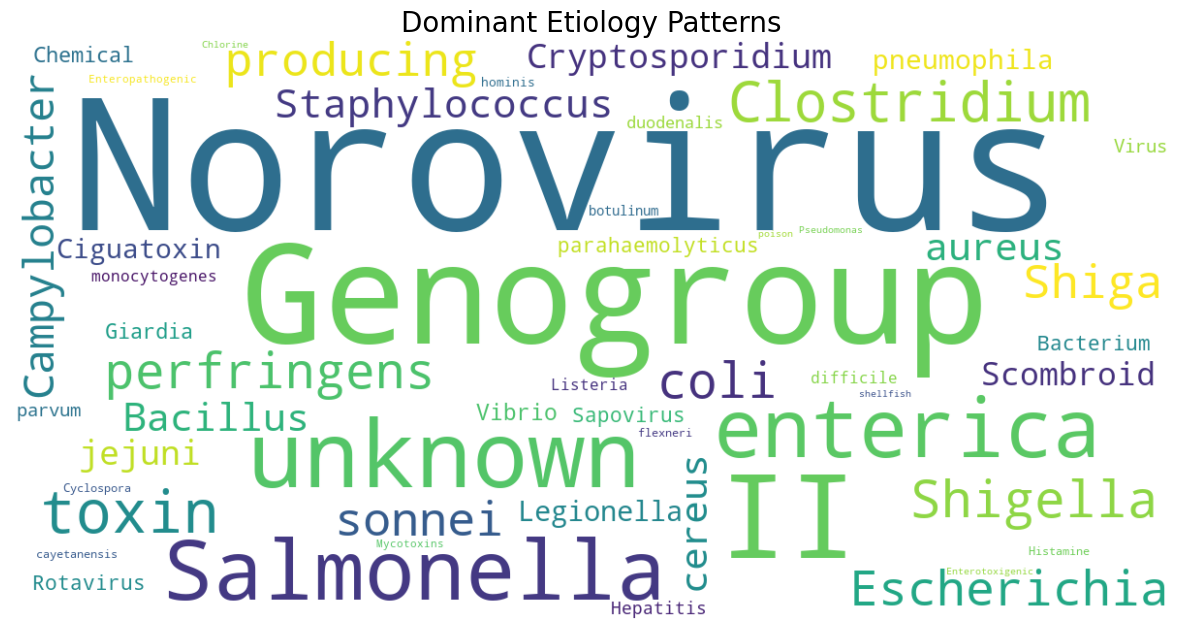

In [21]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from collections import Counter
import re

# 1. Combine all data into one giant string
text = ' '.join(df['Etiology'].dropna().astype(str).values)


# 3. Generate Word Cloud
wordcloud = WordCloud(
    width=1200, 
    height=600, 
    background_color='white',
    collocations=False,  
    min_font_size=10
).generate(text)

words_only = re.findall(r'\w+', text.lower())
word_freq = Counter(words_only)

# 5. Show the most dominant causes
print("--- Most Dominant Etiologies ---")
for word, count in word_freq.most_common(10):
    print(f"{word.upper()}: {count} occurrences")

# 6. Plot the Cloud
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Dominant Etiology Patterns', fontsize=20)
plt.show()

[('Norovirus', 21422), ('Salmonella', 3439), ('Clostridium', 1161), ('Shigella', 1145), ('Escherichia', 947), ('Campylobacter', 736), ('Staphylococcus', 638), ('Bacillus', 534), ('Cryptosporidium', 440), ('Scombroid', 419), ('Other', 417), ('Ciguatoxin', 297), ('Legionella', 290), ('Vibrio', 177), ('Giardia', 151), ('Rotavirus', 117), ('Sapovirus', 98), ('Hepatitis', 97), ('Listeria', 79), ('Histamine', 44)]


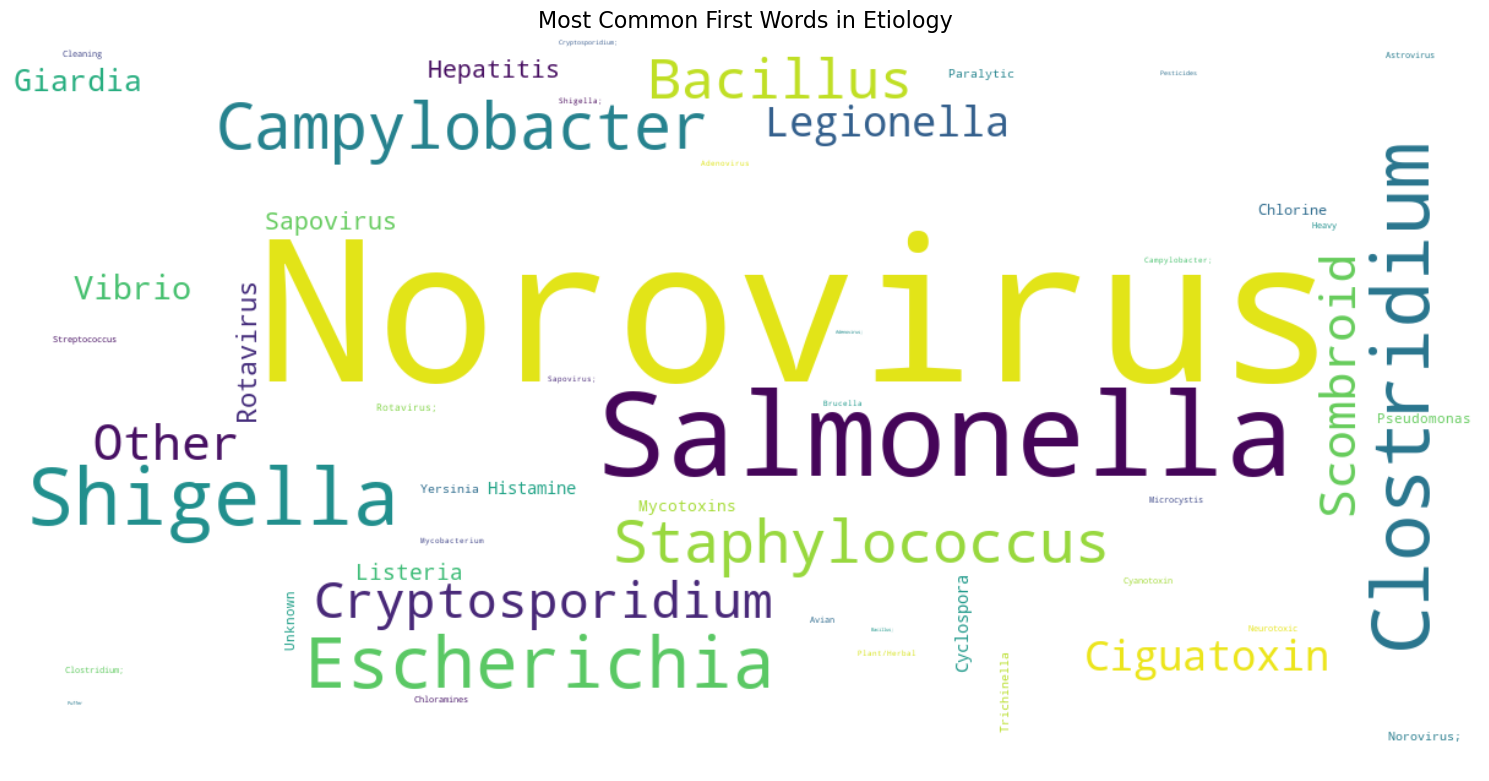

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Get first word of each etiology entry
first_words = df['Etiology'].dropna().str.split().str[0]

# Count frequencies
word_freq = Counter(first_words)
print(word_freq.most_common(20))

# Generate word cloud from frequencies
wordcloud = WordCloud(width=1200, height=600, background_color='white',
                      collocations=False).generate_from_frequencies(word_freq)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common First Words in Etiology', fontsize=16)
plt.tight_layout()
plt.show()

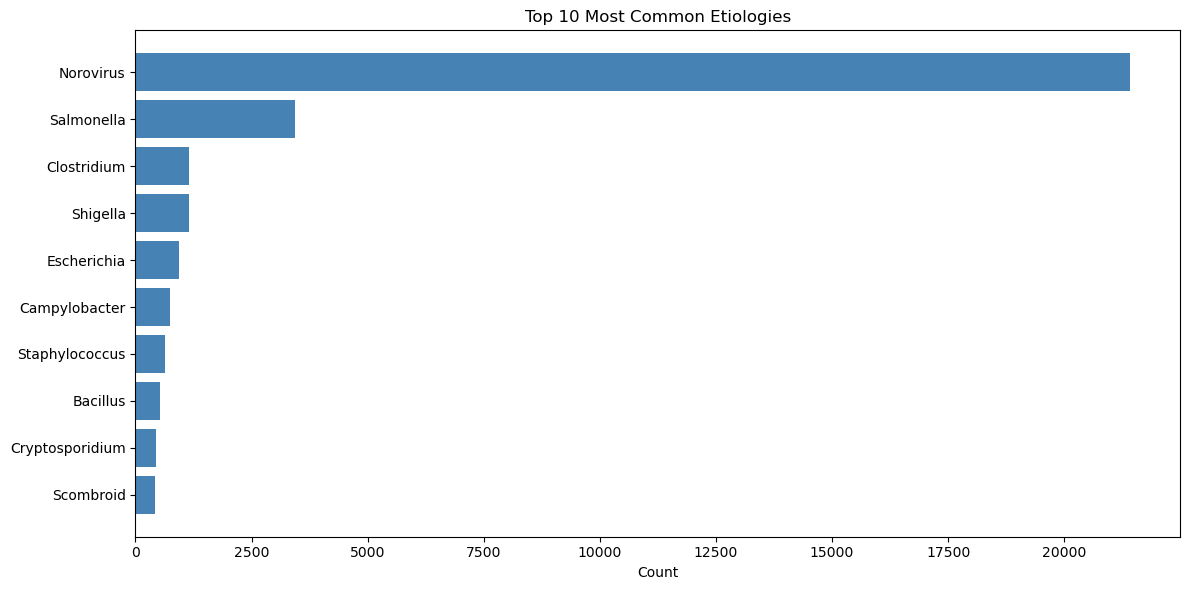

In [20]:
import matplotlib.pyplot as plt
from collections import Counter

# Get first word of each etiology entry
first_words = df['Etiology'].dropna().str.split().str[0]
word_freq = Counter(first_words)

# Top 10
top10 = pd.DataFrame(word_freq.most_common(10), columns=['Etiology', 'Count'])

# Bar chart
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top10['Etiology'], top10['Count'], color='steelblue')
ax.set_title('Top 10 Most Common Etiologies')
ax.set_xlabel('Count')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

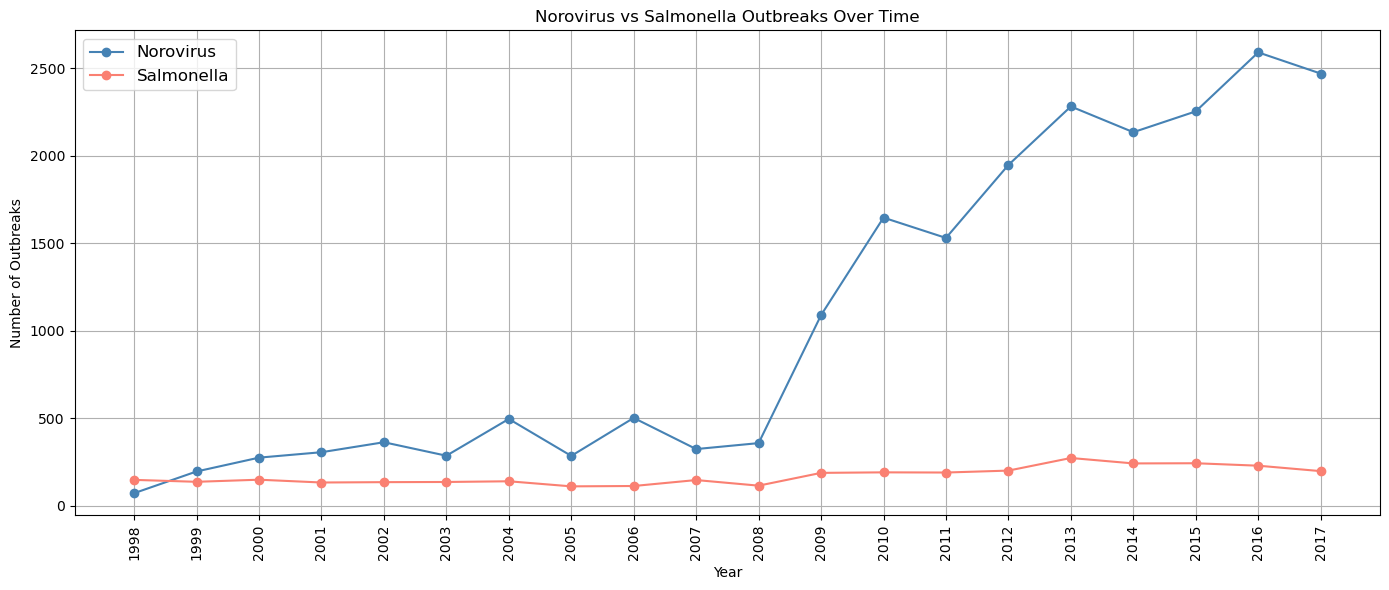

In [22]:
# Filter for Norovirus and Salmonella as first word
df['Etiology First Word'] = df['Etiology'].dropna().str.split().str[0]

norovirus = df[df['Etiology First Word'] == 'Norovirus'].groupby('Year').size()
salmonella = df[df['Etiology First Word'] == 'Salmonella'].groupby('Year').size()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(norovirus.index, norovirus.values, marker='o', label='Norovirus', color='steelblue')
ax.plot(salmonella.index, salmonella.values, marker='o', label='Salmonella', color='salmon')

ax.set_title('Norovirus vs Salmonella Outbreaks Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Outbreaks')
ax.legend(fontsize=12)
ax.grid(True)
ax.set_xticks(sorted(df['Year'].unique()))
ax.set_xticklabels(sorted(df['Year'].unique()), rotation=90)
plt.tight_layout()
plt.show()

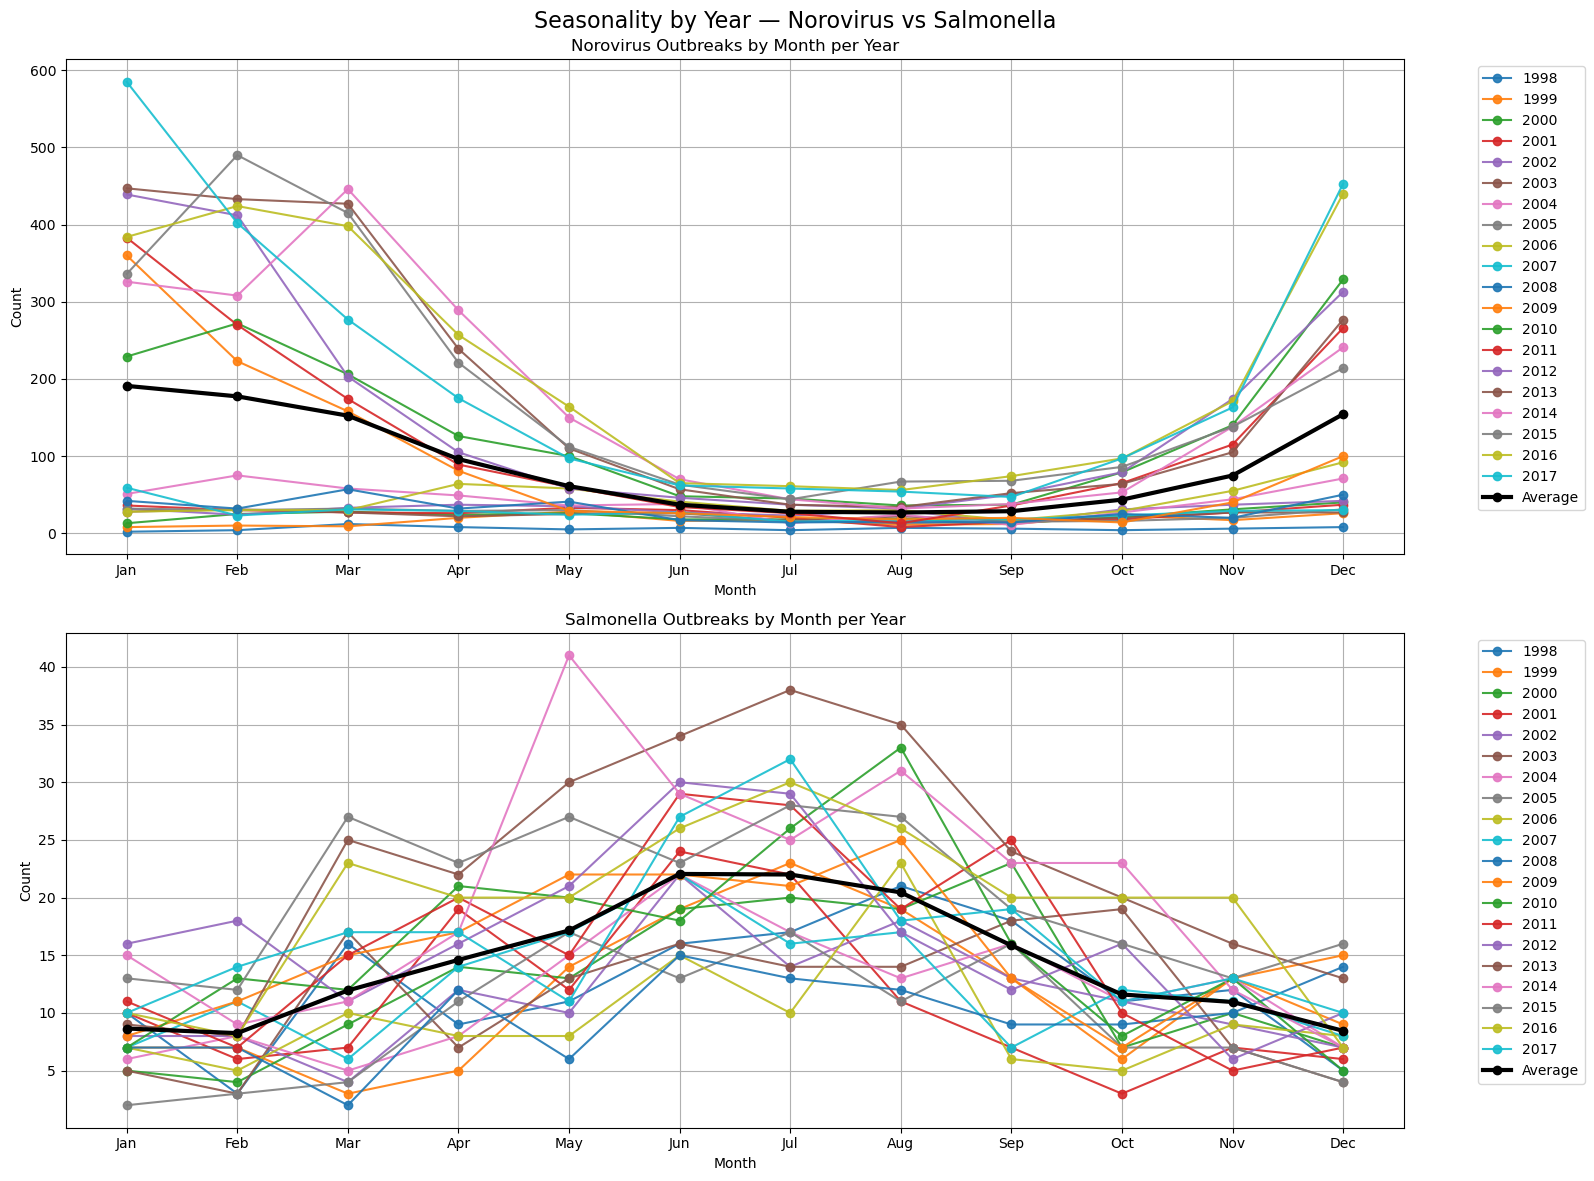

In [23]:
import plotly.graph_objects as go

# Define filtered dataframes just for this cell
norovirus_df = df[df['Etiology First Word'] == 'Norovirus']
salmonella_df = df[df['Etiology First Word'] == 'Salmonella']

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# --- Norovirus by Month per Year ---
for year in sorted(df['Year'].unique()):
    year_data = norovirus_df[norovirus_df['Year'] == year].groupby('Month').size()
    axes[0].plot(year_data.index, year_data.values, marker='o', label=str(year), alpha=.9)

# Average line for Norovirus
norovirus_avg = norovirus_df.groupby('Month').size() / df['Year'].nunique()
axes[0].plot(norovirus_avg.index, norovirus_avg.values, marker='o',
             label='Average', color='black', linewidth=3)
axes[0].set_title('Norovirus Outbreaks by Month per Year')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[0].grid(True)

# --- Salmonella by Month per Year ---
for year in sorted(df['Year'].unique()):
    year_data = salmonella_df[salmonella_df['Year'] == year].groupby('Month').size()
    axes[1].plot(year_data.index, year_data.values, marker='o', label=str(year), alpha=.9)

# Average line for Salmonella
salmonella_avg = salmonella_df.groupby('Month').size() / df['Year'].nunique()
axes[1].plot(salmonella_avg.index, salmonella_avg.values, marker='o',
             label='Average', color='black', linewidth=3)
axes[1].set_title('Salmonella Outbreaks by Month per Year')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[1].grid(True)

plt.suptitle('Seasonality by Year — Norovirus vs Salmonella', fontsize=16)
plt.tight_layout()
plt.show()

In [24]:

import plotly.graph_objects as go
# State abbreviation mapping
state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE','Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY', 'Washington DC': 'DC'
}

df['State Abbrev'] = df['State'].map(state_abbrev)
# Calculate global min and max for Norovirus
noro_counts = df[df['Etiology First Word'] == 'Norovirus'].groupby(['Year', 'State Abbrev']).size()
noro_min = noro_counts.min()
noro_max = noro_counts.max()

years = sorted(df['Year'].unique())

# Build frames
frames = []
for year in years:
    year_data = df[df['Year'] == year]
    norovirus_state = year_data[year_data['Etiology First Word'] == 'Norovirus'].groupby('State Abbrev').size().reset_index(name='Count')
    frames.append(go.Frame(
        data=[go.Choropleth(
            locations=norovirus_state['State Abbrev'],
            z=norovirus_state['Count'],
            locationmode='USA-states',
            colorscale='Blues',
            zmin=noro_min,
            zmax=noro_max,
            colorbar=dict(title='Outbreaks')
        )],
        name=str(year)
    ))

# Initial frame
first_year = df[df['Year'] == years[0]]
first_state = first_year[first_year['Etiology First Word'] == 'Norovirus'].groupby('State Abbrev').size().reset_index(name='Count')

fig = go.Figure(
    data=[go.Choropleth(
        locations=first_state['State Abbrev'],
        z=first_state['Count'],
        locationmode='USA-states',
        colorscale='Blues',
        zmin=noro_min,
        zmax=noro_max,
        colorbar=dict(title='Outbreaks')
    )],
    frames=frames
)

fig.update_layout(
    title='Norovirus Outbreaks by State and Year',
    geo_scope='usa',
    sliders=[{
        'steps': [{'args': [[str(y)], {'frame': {'duration': 0}, 'mode': 'immediate'}],
                   'label': str(y), 'method': 'animate'} for y in years],
        'currentvalue': {'prefix': 'Year: '}
    }],
    updatemenus=[{
        'type': 'buttons',
        'buttons': [
            {'label': 'Play', 'method': 'animate', 'args': [None, {'frame': {'duration': 800}}]},
            {'label': 'Pause', 'method': 'animate', 'args': [[None], {'mode': 'immediate'}]}
        ]
    }],
    width=1000,
    height=600
)

fig.show()

In [25]:
import plotly.graph_objects as go

# Calculate global min and max for Salmonella
salm_counts = df[df['Etiology First Word'] == 'Salmonella'].groupby(['Year', 'State Abbrev']).size()
salm_min = salm_counts.min()
salm_max = salm_counts.max()

years = sorted(df['Year'].unique())

# Build frames
frames = []
for year in years:
    year_data = df[df['Year'] == year]
    salmonella_state = year_data[year_data['Etiology First Word'] == 'Salmonella'].groupby('State Abbrev').size().reset_index(name='Count')
    frames.append(go.Frame(
        data=[go.Choropleth(
            locations=salmonella_state['State Abbrev'],
            z=salmonella_state['Count'],
            locationmode='USA-states',
            colorscale='Reds',
            zmin=salm_min,
            zmax=salm_max,
            colorbar=dict(title='Outbreaks')
        )],
        name=str(year)
    ))

# Initial frame
first_year = df[df['Year'] == years[0]]
first_state = first_year[first_year['Etiology First Word'] == 'Salmonella'].groupby('State Abbrev').size().reset_index(name='Count')

fig = go.Figure(
    data=[go.Choropleth(
        locations=first_state['State Abbrev'],
        z=first_state['Count'],
        locationmode='USA-states',
        colorscale='Reds',
        zmin=salm_min,
        zmax=salm_max,
        colorbar=dict(title='Outbreaks')
    )],
    frames=frames
)

fig.update_layout(
    title='Salmonella Outbreaks by State and Year',
    geo_scope='usa',
    sliders=[{
        'steps': [{'args': [[str(y)], {'frame': {'duration': 0}, 'mode': 'immediate'}],
                   'label': str(y), 'method': 'animate'} for y in years],
        'currentvalue': {'prefix': 'Year: '}
    }],
    updatemenus=[{
        'type': 'buttons',
        'buttons': [
            {'label': 'Play', 'method': 'animate', 'args': [None, {'frame': {'duration': 800}}]},
            {'label': 'Pause', 'method': 'animate', 'args': [[None], {'mode': 'immediate'}]}
        ]
    }],
    width=1000,
    height=600
)

fig.show()

In [26]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Get Primary Mode counts for Norovirus and Salmonella
noro_mode = norovirus_df['Primary Mode'].value_counts()
salm_mode = salmonella_df['Primary Mode'].value_counts()

def prepare_pie(counts, threshold=0.01):
    total = counts.sum()
    main = counts[counts / total >= threshold]
    other = counts[counts / total < threshold].sum()
    if other > 0:
        main['Other'] = other
    return main

noro_pie = prepare_pie(noro_mode)
salm_pie = prepare_pie(salm_mode)

fig = make_subplots(rows=1, cols=2,
                    specs=[[{'type': 'pie'}, {'type': 'pie'}]],
                    subplot_titles=['Norovirus - Primary Mode', 'Salmonella - Primary Mode'])

fig.add_trace(go.Pie(
    labels=noro_pie.index,
    values=noro_pie.values,
    name='Norovirus',
    hole=0.3
), row=1, col=1)

fig.add_trace(go.Pie(
    labels=salm_pie.index,
    values=salm_pie.values,
    name='Salmonella',
    hole=0.3
), row=1, col=2)

fig.update_layout(
    title='Primary Transmission Mode — Norovirus vs Salmonella',
    height=500,
    width=1200
)

fig.show()

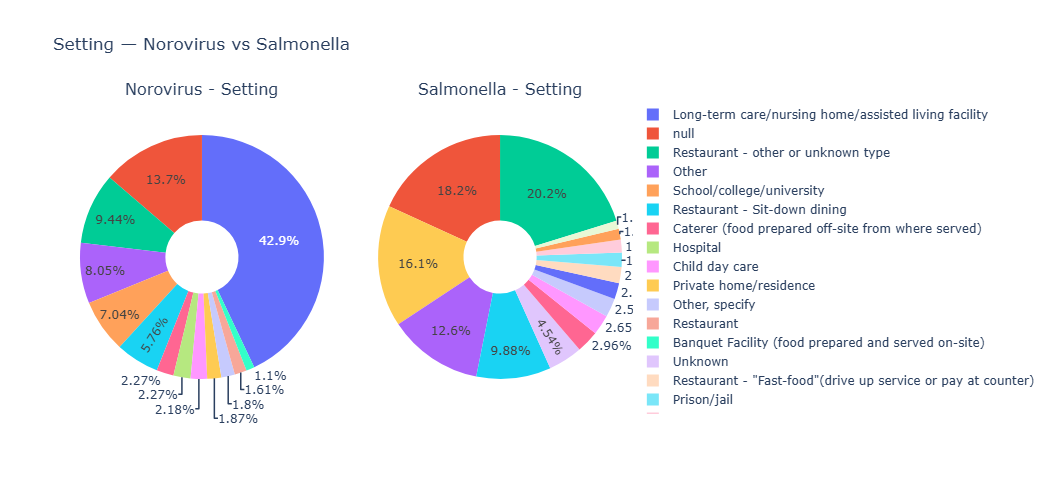

In [27]:
# Get Setting counts for Norovirus and Salmonella
noro_setting = norovirus_df['Setting'].value_counts(dropna=False)
salm_setting = salmonella_df['Setting'].value_counts(dropna=False)

noro_pie = prepare_pie(noro_setting)
salm_pie = prepare_pie(salm_setting)

fig = make_subplots(rows=1, cols=2,
                    specs=[[{'type': 'pie'}, {'type': 'pie'}]],
                    subplot_titles=['Norovirus - Setting', 'Salmonella - Setting'])

fig.add_trace(go.Pie(
    labels=noro_pie.index,
    values=noro_pie.values,
    name='Norovirus',
    hole=0.3
), row=1, col=1)

fig.add_trace(go.Pie(
    labels=salm_pie.index,
    values=salm_pie.values,
    name='Salmonella',
    hole=0.3
), row=1, col=2)

fig.update_layout(
    title='Setting — Norovirus vs Salmonella',
    height=500,
    width=1200
)

fig.show()

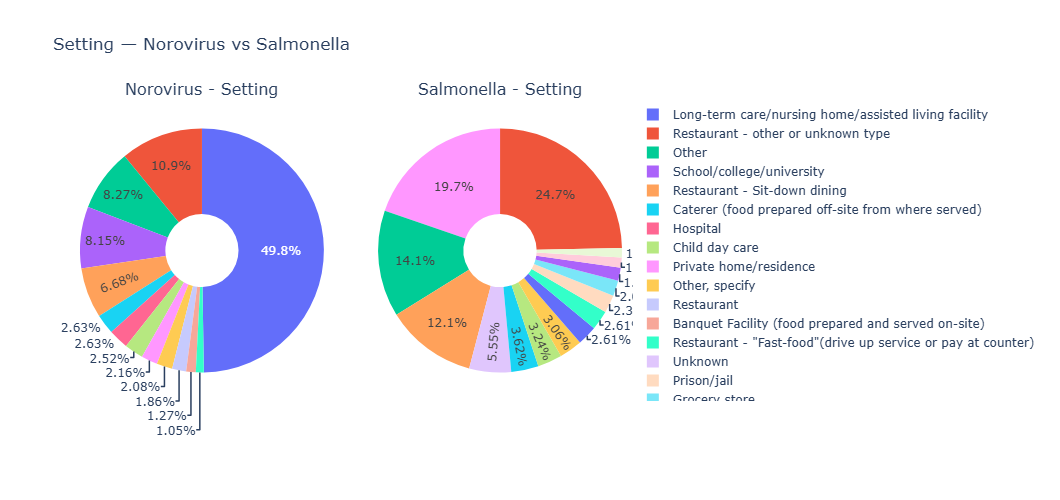

In [28]:
noro_setting_temp = norovirus_df['Setting'].dropna().value_counts()
salm_setting_temp = salmonella_df['Setting'].dropna().value_counts()

noro_pie = prepare_pie(noro_setting_temp)
salm_pie = prepare_pie(salm_setting_temp)

fig = make_subplots(rows=1, cols=2,
                    specs=[[{'type': 'pie'}, {'type': 'pie'}]],
                    subplot_titles=['Norovirus - Setting', 'Salmonella - Setting'])

fig.add_trace(go.Pie(
    labels=noro_pie.index,
    values=noro_pie.values,
    name='Norovirus',
    hole=0.3
), row=1, col=1)

fig.add_trace(go.Pie(
    labels=salm_pie.index,
    values=salm_pie.values,
    name='Salmonella',
    hole=0.3
), row=1, col=2)

fig.update_layout(
    title='Setting — Norovirus vs Salmonella',
    height=500,
    width=1200
)

fig.show()

Top 20 Food Vehicles for Norovirus:
[('salad', 562), ('sandwich', 285), ('salads', 169), ('chicken', 153), ('fruit', 116), ('ice', 113), ('multiple', 113), ('oysters', 111), ('cake', 103), ('lettuce', 102), ('raw', 97), ('beef', 88), ('foods', 87), ('cheese', 77), ('lettuce-based', 75), ('potato', 74), ('deli', 73), ('green', 73), ('turkey', 64), ('pizza', 58)]


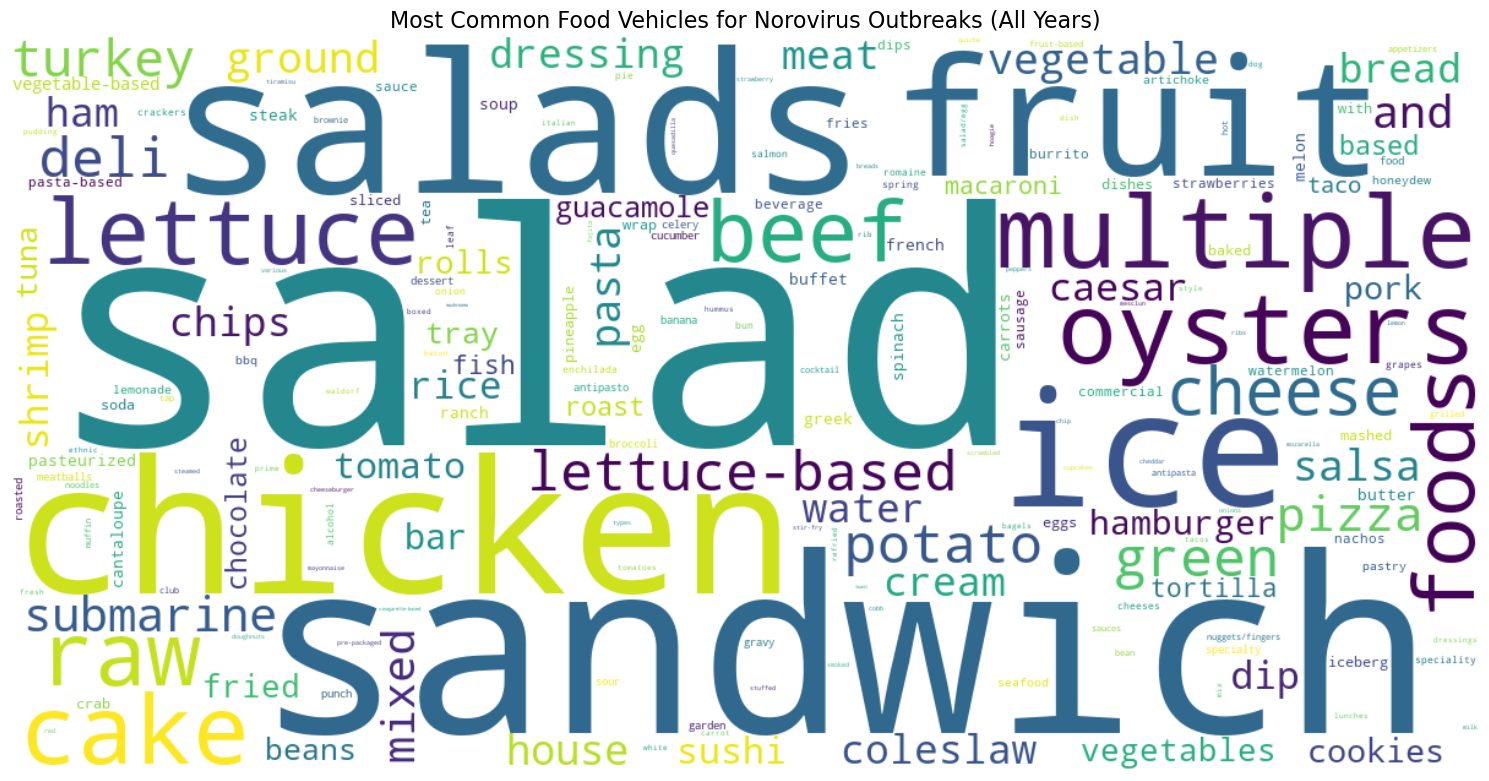


Most Popular Food Word by Year (Norovirus + Food outbreaks):
1998: salad (12 times)
1999: salad (28 times)
2000: salad (32 times)
2001: salad (38 times)
2002: salad (40 times)
2003: salad (33 times)
2004: salad (49 times)
2005: salad (31 times)
2006: salad (47 times)
2007: salad (26 times)
2008: salad (44 times)
2009: salad (17 times)
2010: salad (33 times)
2011: salad (21 times)
2012: salad (18 times)
2013: salad (17 times)
2014: salad (24 times)
2015: salad (13 times)
2016: salad (17 times)
2017: salad (22 times)


In [29]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from collections import Counter
import re

# Filter for Norovirus + Food transmission
noro_food = df[(df['Etiology First Word'] == 'Norovirus') & 
               (df['Primary Mode'] == 'Food')]

# Custom stopwords
custom_stopwords = {'unknown', 'other', 'Other', 'Unknown', 'NaN', 'nan', 'unspecified'}

# --- Overall Word Cloud ---
text = ' '.join(noro_food['Food Vehicle'].dropna().values)
text = re.sub(r'[;,]', ' ', text)
word_list = [w for w in text.split() if w not in custom_stopwords]
word_freq = Counter(word_list)

print("Top 20 Food Vehicles for Norovirus:")
print(word_freq.most_common(20))

wordcloud = WordCloud(width=1200, height=600, background_color='white',
                      collocations=False).generate_from_frequencies(word_freq)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Food Vehicles for Norovirus Outbreaks (All Years)', fontsize=16)
plt.tight_layout()
plt.show()

# --- Most Popular Word Per Year ---
yearly_top = {}
for year in sorted(df['Year'].unique()):
    year_data = noro_food[noro_food['Year'] == year]
    text = ' '.join(year_data['Food Vehicle'].dropna().values)
    text = re.sub(r'[;,]', ' ', text)
    word_list = [w for w in text.split() if w not in custom_stopwords]
    if word_list:
        top_word = Counter(word_list).most_common(1)[0]
        yearly_top[year] = top_word

print("\nMost Popular Food Word by Year (Norovirus + Food outbreaks):")
for year, (word, count) in yearly_top.items():
    print(f"{year}: {word} ({count} times)")

Top 20 Food Vehicles for Salmonella:
[('chicken', 300), ('salad', 120), ('pork', 118), ('eggs', 117), ('beef', 105), ('turkey', 84), ('bbq', 62), ('ground', 54), ('sandwich', 53), ('cheese', 47), ('roasted', 43), ('cream', 42), ('and', 40), ('sprouts', 38), ('ice', 35), ('potato', 34), ('raw', 34), ('rice', 33), ('multiple', 33), ('tomato', 31)]


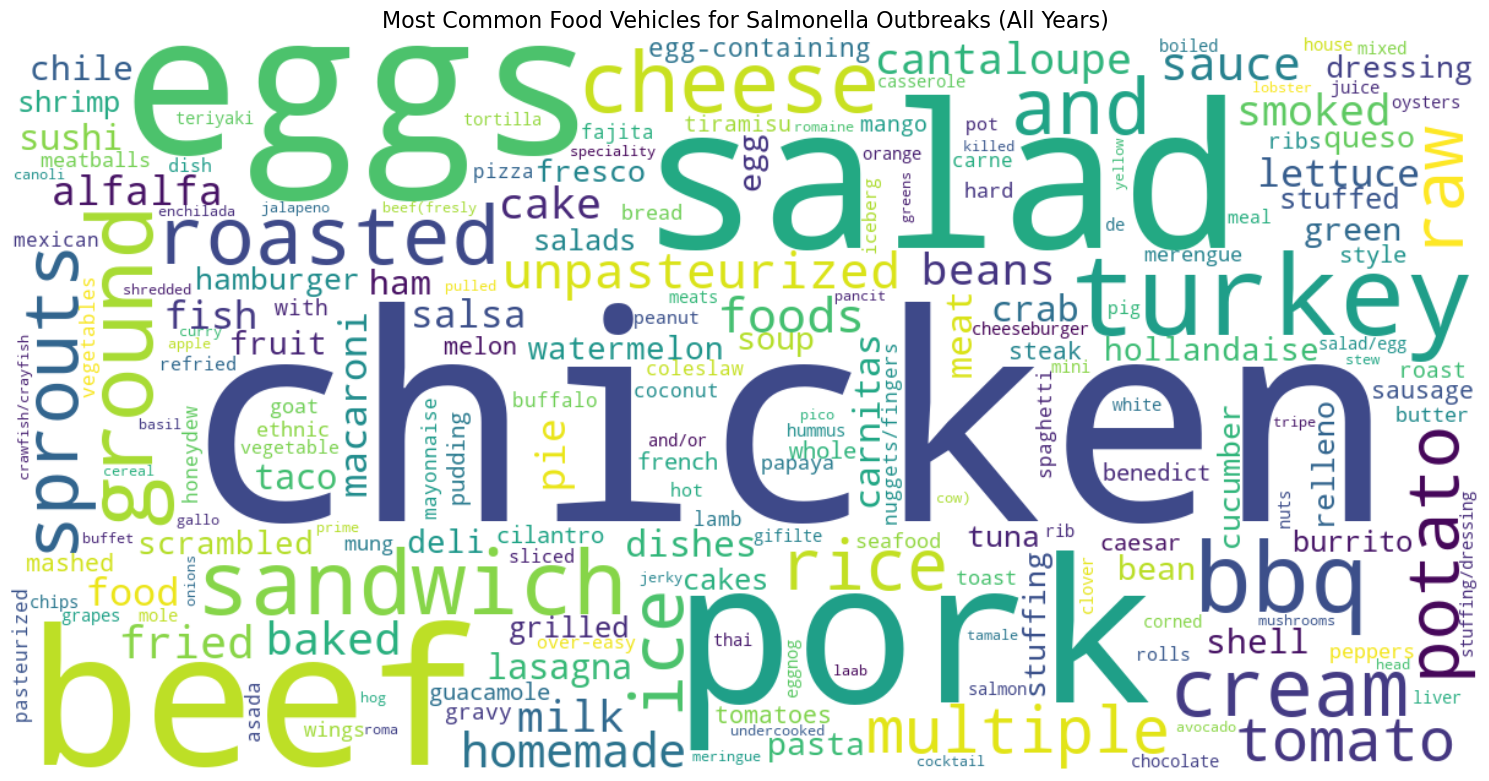


Most Popular Food Word by Year (Salmonella + Food outbreaks):
1998: chicken (20 times)
1999: chicken (24 times)
2000: chicken (18 times)
2001: chicken (18 times)
2002: chicken (15 times)
2003: chicken (19 times)
2004: chicken (16 times)
2005: chicken (18 times)
2006: chicken (11 times)
2007: chicken (9 times)
2008: chicken (10 times)
2009: pork (6 times)
2010: chicken (11 times)
2011: pork (10 times)
2012: chicken (15 times)
2013: chicken (21 times)
2014: chicken (17 times)
2015: chicken (16 times)
2016: chicken (13 times)
2017: chicken (16 times)


In [30]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from collections import Counter
import re

# Filter for Salmonella + Food transmission
salm_food = df[(df['Etiology First Word'] == 'Salmonella') & 
               (df['Primary Mode'] == 'Food')]

# Custom stopwords
custom_stopwords = {'unknown', 'other', 'Other', 'Unknown', 'NaN', 'nan', 'unspecified'}

# --- Overall Word Cloud ---
text = ' '.join(salm_food['Food Vehicle'].dropna().values)
text = re.sub(r'[;,]', ' ', text)
word_list = [w for w in text.split() if w not in custom_stopwords]
word_freq = Counter(word_list)

print("Top 20 Food Vehicles for Salmonella:")
print(word_freq.most_common(20))

wordcloud = WordCloud(width=1200, height=600, background_color='white',
                      collocations=False).generate_from_frequencies(word_freq)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Food Vehicles for Salmonella Outbreaks (All Years)', fontsize=16)
plt.tight_layout()
plt.show()

# --- Most Popular Word Per Year ---
yearly_top = {}
for year in sorted(df['Year'].unique()):
    year_data = salm_food[salm_food['Year'] == year]
    text = ' '.join(year_data['Food Vehicle'].dropna().values)
    text = re.sub(r'[;,]', ' ', text)
    word_list = [w for w in text.split() if w not in custom_stopwords]
    if word_list:
        top_word = Counter(word_list).most_common(1)[0]
        yearly_top[year] = top_word

print("\nMost Popular Food Word by Year (Salmonella + Food outbreaks):")
for year, (word, count) in yearly_top.items():
    print(f"{year}: {word} ({count} times)")

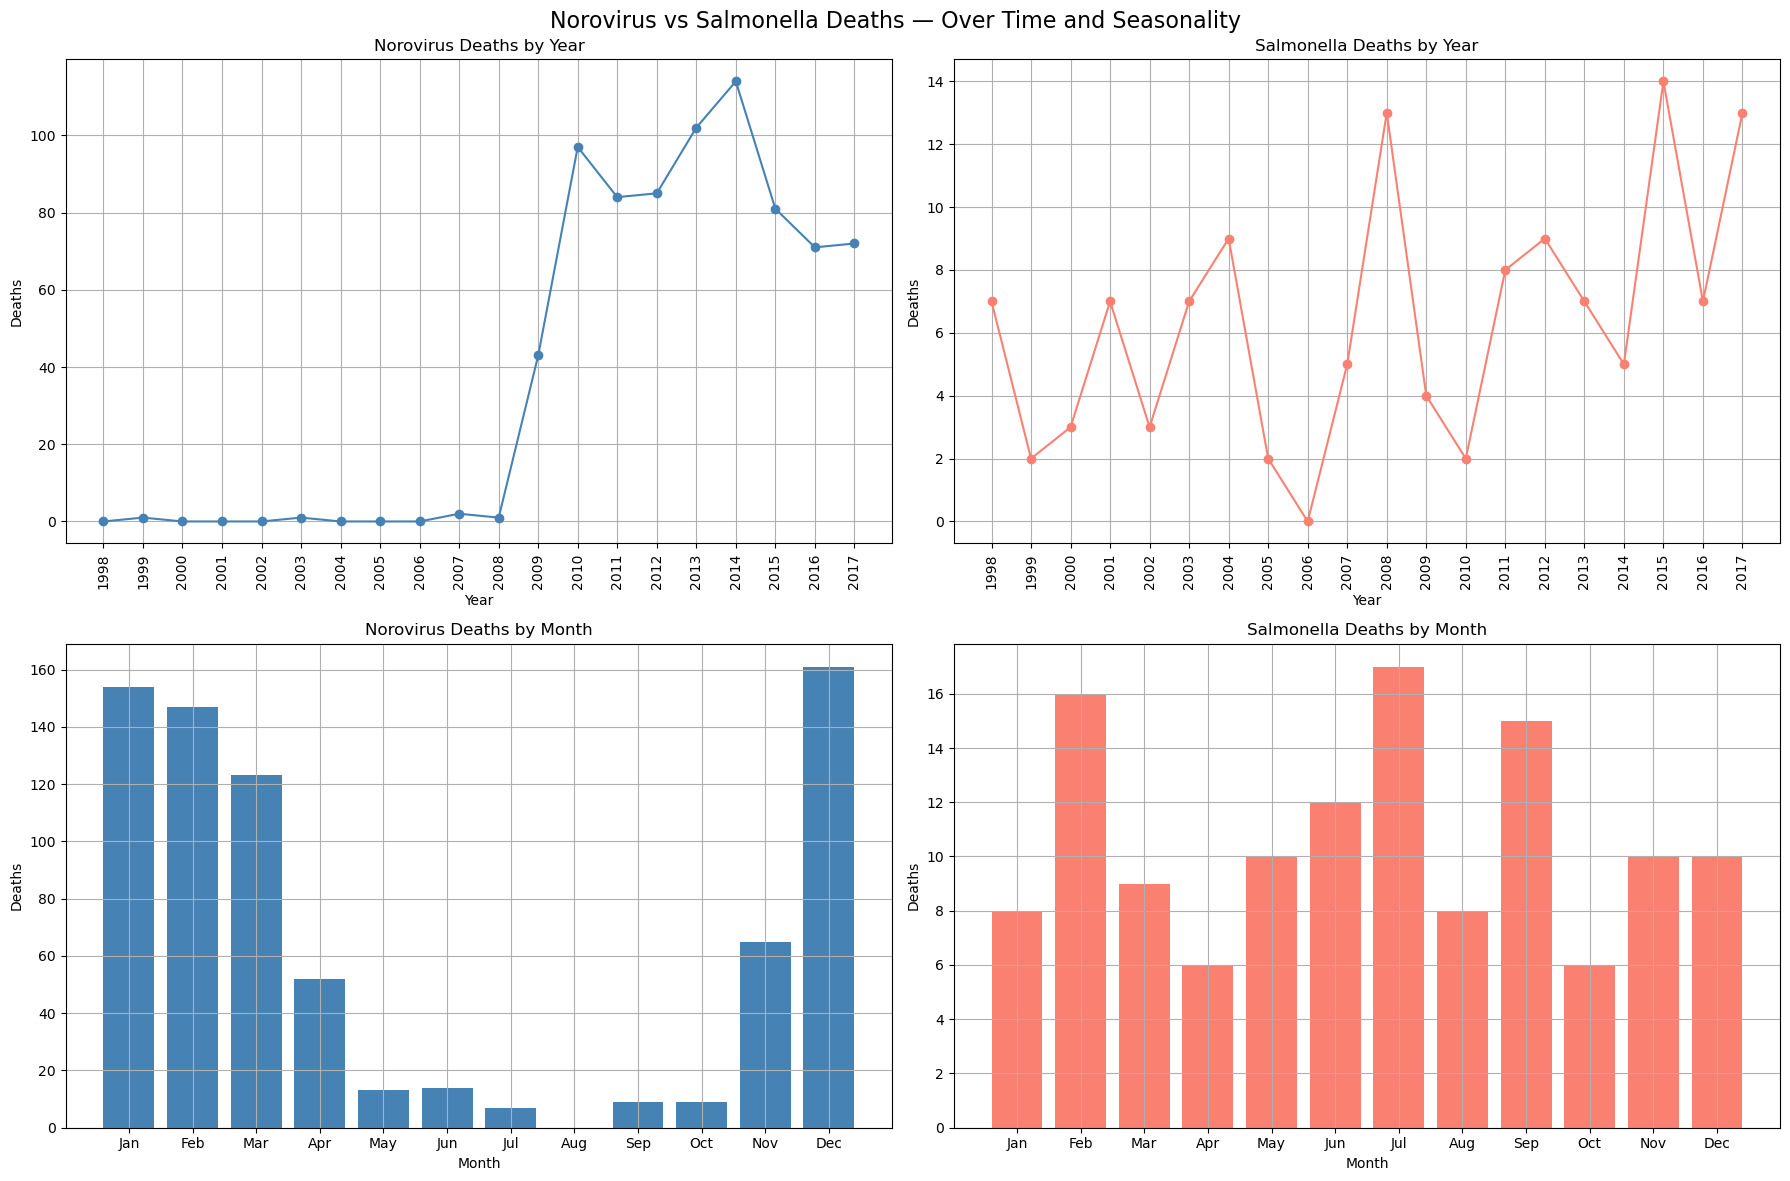

In [31]:
# Deaths over time by year
noro_deaths = df[df['Etiology First Word'] == 'Norovirus'].groupby('Year')['Deaths'].sum()
salm_deaths = df[df['Etiology First Word'] == 'Salmonella'].groupby('Year')['Deaths'].sum()

# Deaths by month
noro_deaths_month = df[df['Etiology First Word'] == 'Norovirus'].groupby('Month')['Deaths'].sum()
salm_deaths_month = df[df['Etiology First Word'] == 'Salmonella'].groupby('Month')['Deaths'].sum()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- Norovirus Deaths by Year ---
axes[0, 0].plot(noro_deaths.index, noro_deaths.values, marker='o', color='steelblue')
axes[0, 0].set_title('Norovirus Deaths by Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Deaths')
axes[0, 0].set_xticks(sorted(df['Year'].unique()))
axes[0, 0].set_xticklabels(sorted(df['Year'].unique()), rotation=90)
axes[0, 0].grid(True)

# --- Salmonella Deaths by Year ---
axes[0, 1].plot(salm_deaths.index, salm_deaths.values, marker='o', color='salmon')
axes[0, 1].set_title('Salmonella Deaths by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Deaths')
axes[0, 1].set_xticks(sorted(df['Year'].unique()))
axes[0, 1].set_xticklabels(sorted(df['Year'].unique()), rotation=90)
axes[0, 1].grid(True)

# --- Norovirus Deaths by Month ---
axes[1, 0].bar(noro_deaths_month.index, noro_deaths_month.values, color='steelblue')
axes[1, 0].set_title('Norovirus Deaths by Month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Deaths')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                             'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1, 0].grid(True)

# --- Salmonella Deaths by Month ---
axes[1, 1].bar(salm_deaths_month.index, salm_deaths_month.values, color='salmon')
axes[1, 1].set_title('Salmonella Deaths by Month')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Deaths')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                             'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1, 1].grid(True)

plt.suptitle('Norovirus vs Salmonella Deaths — Over Time and Seasonality', fontsize=16)
plt.tight_layout()
plt.show()